<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/05_model_comparison_pipeline_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Master Model Comparison & Persona Profiling


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
PROJECT_ROOT = '/content/drive/MyDrive/project'

PATHS = {
    'kmeans_metrics':     f'{PROJECT_ROOT}/metrics/kmeans_results.json',
    'hier_metrics':       f'{PROJECT_ROOT}/metrics/hierarchical_results.json',
    'gmm_metrics':        f'{PROJECT_ROOT}/metrics/gmm_results.json',
    'kmeans_model':       f'{PROJECT_ROOT}/models/kmeans_model.pkl',
    'hier_model':         f'{PROJECT_ROOT}/models/hierarchical_model.pkl',
    'gmm_model':          f'{PROJECT_ROOT}/models/gmm_model.pkl',
    'scaler':             f'{PROJECT_ROOT}/models/rfm_scaler.pkl',
    'preprocessed_csv':   f'{PROJECT_ROOT}/data/preprocessed_rfm_scaled.csv',
    'comparison_png':     f'{PROJECT_ROOT}/data/comparison_pca_side_by_side.png',
    'heatmap_png':        f'{PROJECT_ROOT}/data/persona_heatmap.png',
    'radar_png':          f'{PROJECT_ROOT}/data/persona_radar.png',
    'final_pipeline':     f'{PROJECT_ROOT}/models/final_unified_pipeline.pkl',
    'persona_labels':     f'{PROJECT_ROOT}/models/persona_labels.pkl',
    'final_summary_json': f'{PROJECT_ROOT}/metrics/final_comparison_summary.json',
}
sys.path.insert(0, PROJECT_ROOT)
from rfm_pipeline import RFMFeatureTransformer, FEATURE_ORDER

sns.set_style('whitegrid')
RANDOM_STATE = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 3.1: Comparative Performance Analysis

In [8]:
kmeans_res = json.load(open(PATHS['kmeans_metrics']))
hier_res = json.load(open(PATHS['hier_metrics']))
gmm_res = json.load(open(PATHS['gmm_metrics']))

raw_summary = pd.DataFrame([
    {'Member': 'Student 1', 'Algorithm': 'K-Means', 'Optimal Parameters': kmeans_res['best_params'],
     'Silhouette (own eval)': kmeans_res['best_metrics']['silhouette_score'],
     'Davies-Bouldin (own eval)': kmeans_res['best_metrics']['davies_bouldin_index'],
     'Calinski-Harabasz (own eval)': kmeans_res['best_metrics']['calinski_harabasz_index']},
    {'Member': 'Student 2', 'Algorithm': 'Hierarchical', 'Optimal Parameters': hier_res['best_params'],
     'Silhouette (own eval)': hier_res['best_metrics']['silhouette_score'],
     'Davies-Bouldin (own eval)': hier_res['best_metrics']['davies_bouldin_index'],
     'Calinski-Harabasz (own eval)': hier_res['best_metrics']['calinski_harabasz_index']},
    {'Member': 'Student 3', 'Algorithm': 'GMM', 'Optimal Parameters': gmm_res['best_params'],
     'Silhouette (own eval)': gmm_res['best_metrics']['silhouette_score'],
     'Davies-Bouldin (own eval)': gmm_res['best_metrics']['davies_bouldin_index'],
     'Calinski-Harabasz (own eval)': gmm_res['best_metrics']['calinski_harabasz_index']},
])
raw_summary


,Member,Algorithm,Optimal Parameters,Silhouette (own eval),Davies-Bouldin (own eval),Calinski-Harabasz (own eval)
0,Student 1,K-Means,"{'k': 4, 'init': 'random', 'n_init': 20}",0.205737,1.487742,14043.419151
1,Student 2,Hierarchical,"{'k': 4, 'linkage': 'complete', 'metric': 'euc...",0.296287,1.467022,650.635054
2,Student 3,GMM,"{'n_components': 4, 'covariance_type': 'tied'}",0.266871,1.494154,7188.976784


In [9]:
kmeans_model = joblib.load(PATHS['kmeans_model'])
hier_model = joblib.load(PATHS['hier_model'])
gmm_model = joblib.load(PATHS['gmm_model'])
scaler = joblib.load(PATHS['scaler'])

df = pd.read_csv(PATHS['preprocessed_csv'])
feature_cols = FEATURE_ORDER
scaled_cols = [c + '_scaled' for c in feature_cols]
X_full = df[scaled_cols].values


hier_sample = df.sample(n=hier_res['sample_size_used'], random_state=RANDOM_STATE)
hier_sample_X = hier_sample[scaled_cols].values
hier_sample_labels = hier_model.fit_predict(hier_sample_X)
hier_predictor = KNeighborsClassifier(n_neighbors=5).fit(hier_sample_X, hier_sample_labels)

print("Hierarchical predictor: 5-NN surrogate trained on its 4,000-customer fit sample.")


Hierarchical predictor: 5-NN surrogate trained on its 4,000-customer fit sample.


In [10]:

eval_idx = df.sample(n=5000, random_state=RANDOM_STATE).index
X_eval = X_full[eval_idx]

eval_labels = {
    'K-Means': kmeans_model.predict(X_eval),
    'Hierarchical': hier_predictor.predict(X_eval),
    'GMM': gmm_model.predict(X_eval),
}

fair_summary = pd.DataFrame([
    {'Member': 'Student 1', 'Algorithm': 'K-Means', 'Optimal Parameters': str(kmeans_res['best_params']),
     'Silhouette Score (↑)': silhouette_score(X_eval, eval_labels['K-Means']),
     'Davies-Bouldin Index (↓)': davies_bouldin_score(X_eval, eval_labels['K-Means']),
     'Calinski-Harabasz Index (↑)': calinski_harabasz_score(X_eval, eval_labels['K-Means'])},
    {'Member': 'Student 2', 'Algorithm': 'Hierarchical', 'Optimal Parameters': str(hier_res['best_params']),
     'Silhouette Score (↑)': silhouette_score(X_eval, eval_labels['Hierarchical']),
     'Davies-Bouldin Index (↓)': davies_bouldin_score(X_eval, eval_labels['Hierarchical']),
     'Calinski-Harabasz Index (↑)': calinski_harabasz_score(X_eval, eval_labels['Hierarchical'])},
    {'Member': 'Student 3', 'Algorithm': 'GMM', 'Optimal Parameters': str(gmm_res['best_params']),
     'Silhouette Score (↑)': silhouette_score(X_eval, eval_labels['GMM']),
     'Davies-Bouldin Index (↓)': davies_bouldin_score(X_eval, eval_labels['GMM']),
     'Calinski-Harabasz Index (↑)': calinski_harabasz_score(X_eval, eval_labels['GMM'])},
])

winner_algo = fair_summary.loc[fair_summary['Silhouette Score (↑)'].idxmax(), 'Algorithm']
fair_summary['Winner?'] = fair_summary['Algorithm'].apply(lambda a: '✅' if a == winner_algo else '❌')
fair_summary = fair_summary.round(4)
print(f"Winning algorithm (highest Silhouette Score on the shared 5,000-customer evaluation sample): {winner_algo}")
fair_summary


Winning algorithm (highest Silhouette Score on the shared 5,000-customer evaluation sample): Hierarchical


,Member,Algorithm,Optimal Parameters,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Winner?
0,Student 1,K-Means,"{'k': 4, 'init': 'random', 'n_init': 20}",0.2057,1.4648,1437.5218,❌
1,Student 2,Hierarchical,"{'k': 4, 'linkage': 'complete', 'metric': 'euc...",0.2926,1.4810,787.5985,✅
2,Student 3,GMM,"{'n_components': 4, 'covariance_type': 'tied'}",0.2669,1.4744,775.0490,❌


## Step 3.2: Side-by-Side PCA Visualization

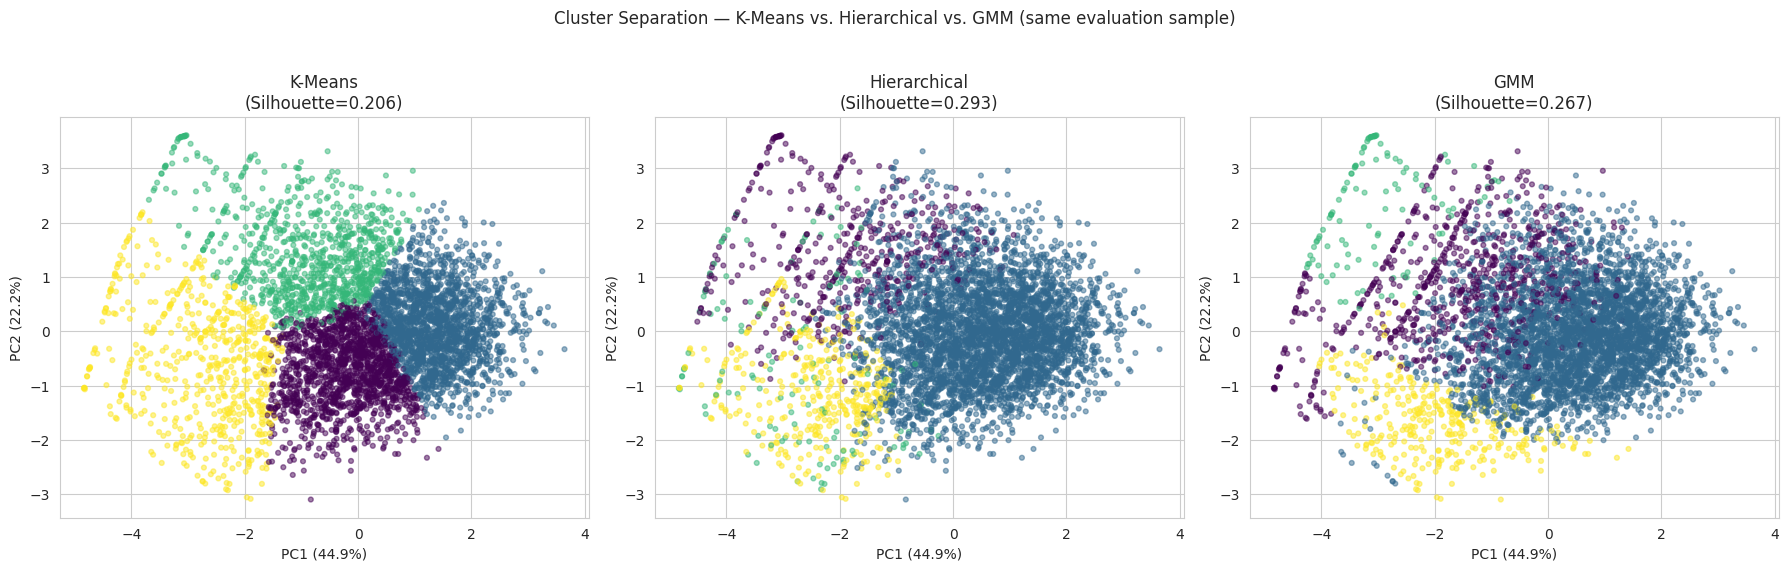

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs_eval = pca.fit_transform(X_eval)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, algo in zip(axes, ['K-Means', 'Hierarchical', 'GMM']):
    sc = ax.scatter(pcs_eval[:, 0], pcs_eval[:, 1], c=eval_labels[algo], cmap='viridis', alpha=0.5, s=12)
    ax.set_title(f'{algo}\n(Silhouette={fair_summary.set_index("Algorithm").loc[algo, "Silhouette Score (↑)"]:.3f})')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.suptitle('Cluster Separation — K-Means vs. Hierarchical vs. GMM (same evaluation sample)', y=1.03)
plt.tight_layout()
plt.savefig(PATHS['comparison_png'], dpi=110, bbox_inches='tight')
plt.show()


## Step 3.3: Behavioral Persona Profiling
Using the predictions from the winning algorithm, assigned to every customer in the full dataset.

In [12]:
winner_predictor = {'K-Means': kmeans_model, 'Hierarchical': hier_predictor, 'GMM': gmm_model}[winner_algo]
df['cluster'] = winner_predictor.predict(X_full)
cluster_counts = df['cluster'].value_counts().sort_index()
print(f"Winning model: {winner_algo}  |  Clusters found: {df['cluster'].nunique()}")
cluster_counts


Winning model: Hierarchical  |  Clusters found: 4


,count
cluster,
0,4593
1,40181
2,1258
3,3629


In [13]:
raw_cols = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Return_Rate_Pct']
persona_raw = df.groupby('cluster')[raw_cols].mean().round(1)
persona_raw['Customers'] = cluster_counts
persona_raw


,Recency,Frequency,Monetary,AOV,Return_Rate_Pct,Customers
cluster,,,,,,
0,490.8,2.3,7642.5,3423.6,36.0,4593
1,206.7,5.7,15558.9,2767.6,40.0,40181
2,474.5,2.1,4294.3,2076.1,97.4,1258
3,404.0,2.7,4318.2,1623.9,33.3,3629


In [14]:
def rank_tag(rank, n, low_label, high_label):
    if n <= 2:
        return low_label if rank == 0 else high_label
    third = n / 3
    if rank < third:
        return low_label
    elif rank >= n - third:
        return high_label
    return 'Mid'

n_clusters = len(persona_raw)
recency_rank = persona_raw['Recency'].rank(method='first').astype(int) - 1
monetary_rank = persona_raw['Monetary'].rank(method='first').astype(int) - 1
frequency_rank = persona_raw['Frequency'].rank(method='first').astype(int) - 1
return_rank = persona_raw['Return_Rate_Pct'].rank(method='first').astype(int) - 1

persona_labels = {}
for cid in persona_raw.index:
    recency_tag = rank_tag(recency_rank[cid], n_clusters, 'Recently Active', 'Lapsed/At-Risk')
    value_tag = rank_tag(monetary_rank[cid], n_clusters, 'Budget', 'High-Value')
    freq_tag = rank_tag(frequency_rank[cid], n_clusters, 'Occasional', 'Frequent')
    return_tag = rank_tag(return_rank[cid], n_clusters, 'Low-Return', 'High-Return')
    tags = [t for t in [recency_tag, freq_tag, value_tag, return_tag] if t != 'Mid']
    label = ', '.join(tags) if tags else 'Typical'
    persona_labels[cid] = f'{label} (Cluster {cid})'

persona_table = persona_raw.copy()
persona_table.insert(0, 'Persona', [persona_labels[c] for c in persona_table.index])
persona_table


,Persona,Recency,Frequency,Monetary,AOV,Return_Rate_Pct,Customers
cluster,,,,,,,
0,"Lapsed/At-Risk, Occasional, Low-Return (Cluste...",490.8,2.3,7642.5,3423.6,36.0,4593
1,"Recently Active, Frequent, High-Value (Cluster 1)",206.7,5.7,15558.9,2767.6,40.0,40181
2,"Occasional, Budget, High-Return (Cluster 2)",474.5,2.1,4294.3,2076.1,97.4,1258
3,"Recently Active, Budget, Low-Return (Cluster 3)",404.0,2.7,4318.2,1623.9,33.3,3629


### Behavioral Heatmap

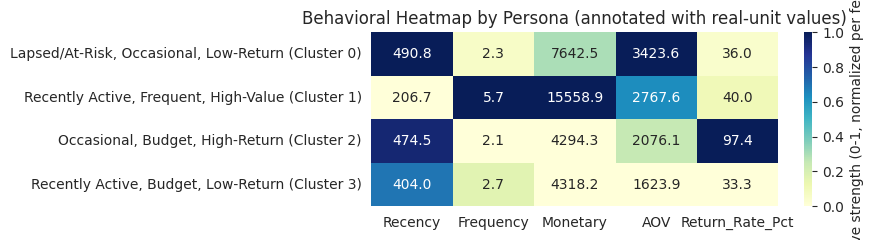

In [15]:
heat_data = persona_raw[raw_cols].copy()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)
heat_norm.index = [persona_labels[c] for c in heat_norm.index]

plt.figure(figsize=(9, max(2.5, 0.6 * len(heat_norm))))
sns.heatmap(heat_norm, annot=heat_data.values, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Relative strength (0-1, normalized per feature)'})
plt.title('Behavioral Heatmap by Persona (annotated with real-unit values)')
plt.tight_layout()
plt.savefig(PATHS['heatmap_png'], dpi=110)
plt.show()


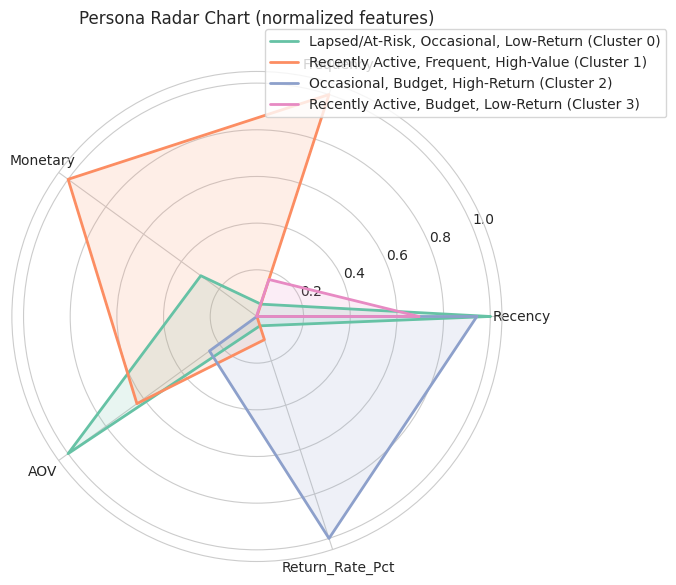

In [16]:
# Radar chart
from math import pi

categories = raw_cols
n_cats = len(categories)
angles = [i / n_cats * 2 * pi for i in range(n_cats)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = sns.color_palette('Set2', len(heat_norm))
for (idx, row), color in zip(heat_norm.iterrows(), colors):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, linewidth=2, label=idx, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Persona Radar Chart (normalized features)', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig(PATHS['radar_png'], dpi=110, bbox_inches='tight')
plt.show()


## Phase 4: Production Pipeline & 1-Click Evaluation Cell
Combine the RFM transformer, the fitted `StandardScaler`, and the winning model estimator into a single `sklearn.pipeline.Pipeline`.

**Note on the Hierarchical case:** if `AgglomerativeClustering` is the winner, `hier_predictor` (the 5-NN surrogate above) is exported in its place, since the raw agglomerative estimator cannot score new/unseen customers — this is the standard, documented way to make hierarchical clustering deployable.

In [17]:
final_pipeline = Pipeline([
    ('rfm_transform', RFMFeatureTransformer()),
    ('scaler', scaler),
    ('cluster', winner_predictor),
])

test_customer = pd.DataFrame([{
    'Recency': 5, 'Frequency': 20, 'Monetary': 15000, 'AOV': 750, 'Return_Rate_Pct': 5,
}])
test_pred = final_pipeline.predict(test_customer)
print(f"Pipeline sanity check -> predicted cluster: {test_pred[0]} ({persona_labels.get(test_pred[0], 'n/a')})")

joblib.dump(final_pipeline, PATHS['final_pipeline'])
joblib.dump(persona_labels, PATHS['persona_labels'])
print(f"Saved {PATHS['final_pipeline']} and {PATHS['persona_labels']}")


Pipeline sanity check -> predicted cluster: 1 (Recently Active, Frequent, High-Value (Cluster 1))
Saved /content/drive/MyDrive/project/models/final_unified_pipeline.pkl and /content/drive/MyDrive/project/models/persona_labels.pkl


### 1-Click Evaluation Cell
Run this cell with any new raw customer inputs to get an instant persona prediction — this is the same call the Gradio app (`app/app.py`) makes.

In [18]:
def evaluate_customer(recency, frequency, monetary, aov, return_rate_pct):
    x = pd.DataFrame([{'Recency': recency, 'Frequency': frequency, 'Monetary': monetary,
                        'AOV': aov, 'Return_Rate_Pct': return_rate_pct}])
    cluster = final_pipeline.predict(x)[0]
    persona = persona_labels.get(cluster, f'Cluster {cluster}')
    return cluster, persona

cluster, persona = evaluate_customer(recency=2, frequency=25, monetary=30000, aov=1200, return_rate_pct=2)
print(f"Example -> Cluster: {cluster}  |  Persona: {persona}")

cluster, persona = evaluate_customer(recency=400, frequency=1, monetary=200, aov=200, return_rate_pct=80)
print(f"Example -> Cluster: {cluster}  |  Persona: {persona}")


Example -> Cluster: 1  |  Persona: Recently Active, Frequent, High-Value (Cluster 1)
Example -> Cluster: 2  |  Persona: Occasional, Budget, High-Return (Cluster 2)


In [19]:
export_summary = {
    'fair_comparison_table': fair_summary.to_dict(orient='records'),
    'winning_algorithm': winner_algo,
    'persona_table': persona_table.reset_index().to_dict(orient='records'),
}
with open(PATHS['final_summary_json'], 'w') as f:
    json.dump(export_summary, f, indent=2, default=str)
print(f"Saved {PATHS['final_summary_json']}")


Saved /content/drive/MyDrive/project/metrics/final_comparison_summary.json
